In [32]:
import torch
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime, date

# Initialize the sentiment classifier
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")

    sentiment_classifier = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True  # This ensures consistent output format
    )
    return sentiment_classifier

In [33]:
# Initialize the analyzer
print("Initializing sentiment analyzer...")
sentiment_classifier = initialize_sentiment_analyzer()

# Function to fetch messages from StockTwits API
def fetch_stocktwits_messages(symbol, max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    messages = []

    try:
        print(f"Fetching messages for {symbol}...")
        response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()
        data = response.json()

        for msg in data.get('messages', [])[:max_messages]:
            messages.append({
                'id': msg['id'],
                'body': msg['body'],
                'created_at': msg['created_at'],
                'user': msg['user']['username']
            })

    except Exception as e:
        print(f"Error fetching messages: {e}")

    return messages

Initializing sentiment analyzer...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [34]:
# Function to analyze sentiment of a single message
def analyze_single_message(text):
    try:
        results = sentiment_classifier(text)
        # The pipeline returns a list of dicts for each label when return_all_scores=True
        sentiment_scores = {result['label']: result['score'] for result in results[0]}
        predicted_sentiment = max(sentiment_scores.items(), key=lambda x: x[1])[0]
        return predicted_sentiment, sentiment_scores
    except Exception as e:
        print(f"Error analyzing message: {e}")
        return "error", {'neutral': 0, 'positive': 0, 'negative': 0}
    
def analyze_messages(messages):
    results = []

    for msg in tqdm(messages, desc="Analyzing sentiment"):
        try:
            text = msg['body']
            sentiment, scores = analyze_single_message(text)

            msg['sentiment'] = sentiment
            msg.update(scores)
            results.append(msg)

        except Exception as e:
            print(f"Error processing message {msg['id']}: {e}")
            msg['sentiment'] = 'error'
            results.append(msg)

    return results

Fetching messages for TSLA...

Analyzing 30 messages...


Analyzing sentiment: 100%|██████████| 30/30 [00:02<00:00, 10.81it/s]



Sample of analyzed messages:
                   datetime          user sentiment  \
0 2025-04-23 01:07:23+00:00  ClosetIguana  negative   
1 2025-04-23 01:07:16+00:00      FredoDog  negative   
2 2025-04-23 01:07:12+00:00        Higreg   neutral   
3 2025-04-23 01:07:06+00:00        IMAUAP  negative   
4 2025-04-23 01:07:01+00:00   Marcbullish  negative   

                                                body  
0  $TSLA So it missed by 2 Billion, with no new g...  
1  $TSLA Yeah.  In many areas they are having fir...  
2                                              $TSLA  
3  $tsla \n\nWhat has not been figured into the T...  
4  $TSLA My neighborhood Tesla dealer always empt...  

Sentiment Distribution:
sentiment
negative    19
neutral      8
positive     3
Name: count, dtype: int64


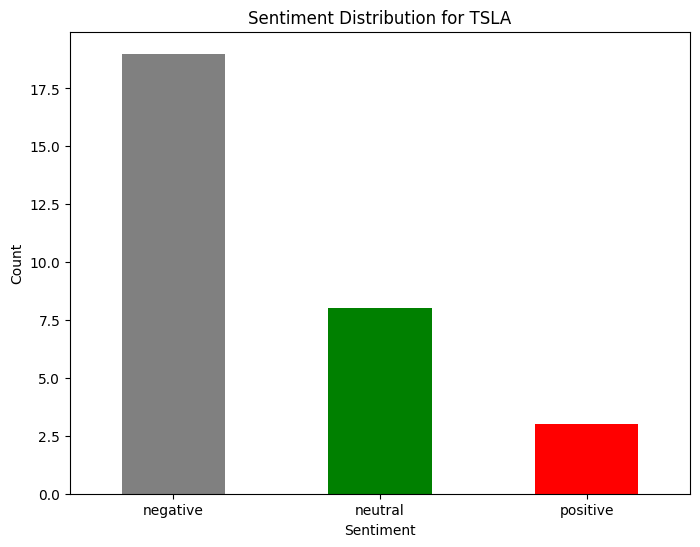

In [35]:
# Main analysis
def main():
    stock_symbol = "TSLA"  # Change to any stock symbol
    messages = fetch_stocktwits_messages(stock_symbol)

    if not messages:
        print("No messages fetched from StockTwits API")
        return

    print(f"\nAnalyzing {len(messages)} messages...")
    analyzed_messages = analyze_messages(messages)

    # Convert to DataFrame for analysis
    df = pd.DataFrame(analyzed_messages)

    # Convert created_at to datetime
    df['datetime'] = pd.to_datetime(df['created_at'])
    df['date'] = df['datetime'].dt.date

    # Show sample of results
    print("\nSample of analyzed messages:")
    print(df[['datetime', 'user', 'sentiment', 'body']].head())

    # Sentiment distribution
    sentiment_counts = df['sentiment'].value_counts()
    print("\nSentiment Distribution:")
    print(sentiment_counts)

    # Plot sentiment distribution
    plt.figure(figsize=(8, 6))
    sentiment_counts.plot(kind='bar', color=['gray', 'green', 'red'])
    plt.title(f'Sentiment Distribution for {stock_symbol}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

    # Save results
    #output_file = f'stocktwits_sentiment_{stock_symbol}.csv'
    #df.to_csv(output_file, index=False)
    #print(f"\nResults saved to {output_file}")

if __name__ == "__main__":
    main()

In [36]:
# Fetch messages + analyze sentiment
def fetch_sentiment_df(symbol="TSLA", max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
    data = response.json()
    
    rows = []
    for msg in data.get('messages', [])[:max_messages]:
        body = msg['body']
        created_at = datetime.fromisoformat(msg['created_at'].replace("Z", "+00:00")).date()
        
        scores_raw = sentiment_classifier(body)[0]
        scores = {res['label']: res['score'] for res in scores_raw}
        
        row = {
            "body": body,
            "date": created_at,
            "positive": scores.get("positive", 0),
            "neutral": scores.get("neutral", 0),
            "negative": scores.get("negative", 0),
            "net_sentiment": scores.get("positive", 0) - scores.get("negative", 0)
        }
        rows.append(row)
    
    return pd.DataFrame(rows)

# Run it
sentiment_df = fetch_sentiment_df("TSLA", max_messages=30)
sentiment_df

,body,date,positive,neutral,negative,net_sentiment
0,"$TSLA So it missed by 2 Billion, with no new g...",2025-04-23,0.190841,0.040944,0.768215,-0.577374
1,$TSLA Yeah. In many areas they are having fir...,2025-04-23,0.061395,0.106888,0.831717,-0.770322
2,$TSLA,2025-04-23,0.169474,0.607430,0.223096,-0.053623
3,$tsla \n\nWhat has not been figured into the T...,2025-04-23,0.031038,0.005520,0.963442,-0.932404
4,$TSLA My neighborhood Tesla dealer always empt...,2025-04-23,0.074344,0.067903,0.857752,-0.783408
5,$TSLA anyone else think trump made these leaks...,2025-04-23,0.025075,0.211567,0.763358,-0.738284
6,$TSLA Lets see 400 now,2025-04-23,0.638612,0.187793,0.173595,0.465017
7,$TSLA 71 percent drop in profits- what part...,2025-04-23,0.000403,0.000113,0.999484,-0.999081
8,$TSLA Protests working👍💥💥🔥🎆🎆,2025-04-23,0.010920,0.015593,0.973487,-0.962567
9,"$TSLA Tesla’s mainstream cars are cheap, espec...",2025-04-23,0.401858,0.550904,0.047238,0.354620


In [37]:
# Aggregate daily sentiment
daily_sentiment = sentiment_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

daily_sentiment

,date,neutral,positive,negative,net_sentiment
0,2025-04-23,0.236884,0.184909,0.578207,-0.393298


In [38]:
import requests
import pandas as pd

API_KEY = '298089a9705e4d05b14894434eb17c25'  # Replace this with your NewsAPI key
query = "Tesla OR TSLA"        # You can modify this query
from_date = "2025-03-23"
to_date = "2025-04-22"

url = "https://newsapi.org/v2/everything"
params = {
    "q": query,
    "from": from_date,
    "to": to_date,
    "language": "en",
    "sortBy": "relevancy",
    "pageSize": 50,
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

# Create DataFrame
if data.get("status") == "ok":
    articles = data.get("articles", [])
    news_df = pd.DataFrame([{
        "date": article["publishedAt"],
        "title": article["title"],
        "source": article["source"]["name"],
        "url": article["url"],
        "description": article["description"]
    } for article in articles])

    print(news_df.head())
else:
    print("Error:", data.get("message"))


                   date                                              title  \
0  2025-03-25T15:52:25Z  Tesla Takedown: all the news about the protest...   
1  2025-04-22T20:18:26Z  Tesla’s revenue and profits tank amid politica...   
2  2025-04-22T22:04:19Z  Tesla is making progress on its 1950s diner an...   
3  2025-04-08T19:00:44Z  Tesla Supercharger damaged in possible explosi...   
4  2025-04-11T14:22:45Z  Tesla’s latest Cybertruck has longer range and...   

      source                                                url  \
0  The Verge  https://www.theverge.com/news/635249/tesla-tak...   
1  The Verge  https://www.theverge.com/news/653645/tesla-q1-...   
2  The Verge  https://www.theverge.com/news/653959/tesla-195...   
3  The Verge  https://www.theverge.com/news/645378/tesla-sup...   
4  The Verge  https://www.theverge.com/news/647060/tesla-cyb...   

                                         description  
0  Since early February, Tesla has been the targe...  
1  Tesla released 

In [39]:
news_df

,date,title,source,url,description
0,2025-03-25T15:52:25Z,Tesla Takedown: all the news about the protest...,The Verge,https://www.theverge.com/news/635249/tesla-tak...,"Since early February, Tesla has been the targe..."
1,2025-04-22T20:18:26Z,Tesla’s revenue and profits tank amid politica...,The Verge,https://www.theverge.com/news/653645/tesla-q1-...,Tesla released its first quarter financial ear...
2,2025-04-22T22:04:19Z,Tesla is making progress on its 1950s diner an...,The Verge,https://www.theverge.com/news/653959/tesla-195...,Tesla has shared new images of its first retro...
3,2025-04-08T19:00:44Z,Tesla Supercharger damaged in possible explosi...,The Verge,https://www.theverge.com/news/645378/tesla-sup...,A Tesla Supercharger station was severely dama...
4,2025-04-11T14:22:45Z,Tesla’s latest Cybertruck has longer range and...,The Verge,https://www.theverge.com/news/647060/tesla-cyb...,Tesla has a new entry-level Cybertruck with lo...
5,2025-03-24T22:45:53Z,The FBI launched a task force to investigate T...,The Verge,https://www.theverge.com/news/635091/fbi-tesla...,A report in the New York Post on Monday reveal...
6,2025-03-31T16:25:57Z,Elon Fiddles While Tesla Dealerships Burn,Gizmodo.com,https://gizmodo.com/elon-fiddles-while-tesla-d...,Someone set fire to a Tesla dealership in Rome...
7,2025-03-29T23:23:17Z,Crowds Turn Out Across the U.S. for ‘Tesla Tak...,Gizmodo.com,https://gizmodo.com/crowds-turn-out-across-the...,Demonstrations against Elon Musk's political i...
8,2025-04-07T21:41:23Z,It’s not looking good for Tesla’s Cybertruck r...,The Verge,https://www.theverge.com/news/644901/tesla-cyb...,Tesla’s battery range extender accessory for C...
9,2025-04-22T21:50:55Z,Elon Musk says he’ll step back from DOGE start...,The Verge,https://www.theverge.com/news/653928/elon-musk...,Elon Musk says he plans to step back from his ...


In [40]:
def analyze_sentiment_from_news_df(df):
    rows = []

    for _, row in df.iterrows():
        # Combine title + description (skip if description is NaN)
        content = f"{row['title']} {row['description']}" if pd.notna(row['description']) else row['title']
        created_at = pd.to_datetime(row['date']).date()

        scores_raw = sentiment_classifier(content)[0]
        scores = {res['label']: res['score'] for res in scores_raw}

        row_out = {
            "title": row["title"],
            "description": row.get("description", ""),
            "date": created_at,
            "source": row["source"],
            "url": row["url"],
            "positive": scores.get("positive", 0),
            "neutral": scores.get("neutral", 0),
            "negative": scores.get("negative", 0),
            "net_sentiment": scores.get("positive", 0) - scores.get("negative", 0)
        }

        rows.append(row_out)

    return pd.DataFrame(rows)


In [41]:
sentiment_news_df = analyze_sentiment_from_news_df(news_df)
sentiment_news_df

,title,description,date,source,url,positive,neutral,negative,net_sentiment
0,Tesla Takedown: all the news about the protest...,"Since early February, Tesla has been the targe...",2025-03-25,The Verge,https://www.theverge.com/news/635249/tesla-tak...,0.008297,0.002644,0.989059,-0.980762
1,Tesla’s revenue and profits tank amid politica...,Tesla released its first quarter financial ear...,2025-04-22,The Verge,https://www.theverge.com/news/653645/tesla-q1-...,0.000302,0.000285,0.999412,-0.999110
2,Tesla is making progress on its 1950s diner an...,Tesla has shared new images of its first retro...,2025-04-22,The Verge,https://www.theverge.com/news/653959/tesla-195...,0.632336,0.363928,0.003736,0.628600
3,Tesla Supercharger damaged in possible explosi...,A Tesla Supercharger station was severely dama...,2025-04-08,The Verge,https://www.theverge.com/news/645378/tesla-sup...,0.001262,0.087839,0.910899,-0.909637
4,Tesla’s latest Cybertruck has longer range and...,Tesla has a new entry-level Cybertruck with lo...,2025-04-11,The Verge,https://www.theverge.com/news/647060/tesla-cyb...,0.673584,0.238024,0.088392,0.585191
5,The FBI launched a task force to investigate T...,A report in the New York Post on Monday reveal...,2025-03-24,The Verge,https://www.theverge.com/news/635091/fbi-tesla...,0.016480,0.436211,0.547309,-0.530829
6,Elon Fiddles While Tesla Dealerships Burn,Someone set fire to a Tesla dealership in Rome...,2025-03-31,Gizmodo.com,https://gizmodo.com/elon-fiddles-while-tesla-d...,0.001684,0.313041,0.685276,-0.683592
7,Crowds Turn Out Across the U.S. for ‘Tesla Tak...,Demonstrations against Elon Musk's political i...,2025-03-29,Gizmodo.com,https://gizmodo.com/crowds-turn-out-across-the...,0.011850,0.296095,0.692055,-0.680205
8,It’s not looking good for Tesla’s Cybertruck r...,Tesla’s battery range extender accessory for C...,2025-04-07,The Verge,https://www.theverge.com/news/644901/tesla-cyb...,0.010758,0.034786,0.954456,-0.943698
9,Elon Musk says he’ll step back from DOGE start...,Elon Musk says he plans to step back from his ...,2025-04-22,The Verge,https://www.theverge.com/news/653928/elon-musk...,0.567755,0.405871,0.026374,0.541381


In [42]:
# Aggregate daily sentiment
daily_sentiment = sentiment_news_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

daily_sentiment

,date,neutral,positive,negative,net_sentiment
0,2025-03-24,0.436211,0.016480,0.547309,-0.530829
1,2025-03-25,0.040912,0.388236,0.570852,-0.182615
2,2025-03-26,0.051900,0.885541,0.062560,0.822981
3,2025-03-27,0.120642,0.002181,0.877177,-0.874996
4,2025-03-28,0.090883,0.160014,0.749104,-0.589090
5,2025-03-29,0.296095,0.011850,0.692055,-0.680205
6,2025-03-30,0.896390,0.008725,0.094885,-0.086160
7,2025-03-31,0.216333,0.005389,0.778278,-0.772889
8,2025-04-02,0.000102,0.000138,0.999759,-0.999621
9,2025-04-03,0.174104,0.198202,0.627694,-0.429492


In [43]:
import requests
import pandas as pd

API_KEY = 'BPX822WG53N2XKT4'

url = "https://www.alphavantage.co/query"
params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "TSLA",
    "apikey": API_KEY,
    "limit": 1000,  # Max articles to fetch
    "time_from": "20200101T0000",
    "time_from": "20210101T0000",
}

response = requests.get(url, params=params)
data = response.json()

# Process news articles
if "feed" in data:
    articles = data["feed"]
    av_df = pd.DataFrame([{
        "title": article["title"],
        "summary": article["summary"],
        "source": article["source"],
        "url": article["url"],
        "time_published": article["time_published"],
        "overall_sentiment_score": article.get("overall_sentiment_score", None)
    } for article in articles])

    print(av_df)
else:
    print("Error:", data)


                                                 title  \
0    Elon Musk Says He'll Only Spend 'Day Or Two Pe...   
1    StopWatt Under Review: Best Energy Saver Devic...   
2    Chinese EV makers take spotlight as Tesla skip...   
3    Readers' Predictions For Tesla Q1 Earnings Res...   
4    Tesla Drive-In Movie Theater, Diner Supercharg...   
..                                                 ...   
666                Why Tesla Stock Is Down Again Today   
667  Memecoins 2.0: The market crashed, but the bil...   
668  The Market's Volatility, CoreWeave's IPO, Bitc...   
669                     Big Week Ahead for Tesla Stock   
670  Trump's Sons Back 'American Bitcoin' With Hut ...   

                                               summary  \
0    Tesla Inc. TSLA CEO Elon Musk said Tuesday tha...   
1    New York City, April 22, 2025 ( GLOBE NEWSWIRE...   
2    Firms including BYD, Nio, Geely, Xiaomi and Le...   
3    Tesla shares are climbing in after-hours tradi...   
4    A Tesla 

In [44]:
av_df["time_published"] = pd.to_datetime(av_df["time_published"], format="%Y%m%dT%H%M%S")
av_df["date"] = av_df["time_published"].dt.date
av_df

,title,summary,source,url,time_published,overall_sentiment_score,date
0,Elon Musk Says He'll Only Spend 'Day Or Two Pe...,Tesla Inc. TSLA CEO Elon Musk said Tuesday tha...,Benzinga,https://www.benzinga.com/25/04/44940401/elon-m...,2025-04-23 00:33:51,0.133241,2025-04-23
1,StopWatt Under Review: Best Energy Saver Devic...,"New York City, April 22, 2025 ( GLOBE NEWSWIRE...",Benzinga,https://www.benzinga.com/pressreleases/25/04/g...,2025-04-22 23:42:38,0.276740,2025-04-22
2,Chinese EV makers take spotlight as Tesla skip...,"Firms including BYD, Nio, Geely, Xiaomi and Le...",South China Morning Post,https://www.scmp.com/business/china-evs/articl...,2025-04-22 23:30:08,0.085168,2025-04-22
3,Readers' Predictions For Tesla Q1 Earnings Res...,Tesla shares are climbing in after-hours tradi...,Benzinga,https://www.benzinga.com/news/management/25/04...,2025-04-22 23:24:00,0.335358,2025-04-22
4,"Tesla Drive-In Movie Theater, Diner Supercharg...",A Tesla Supercharger location will have a dine...,Benzinga,https://www.benzinga.com/general/restaurants/2...,2025-04-22 22:42:14,0.224055,2025-04-22
...,...,...,...,...,...,...,...
666,Why Tesla Stock Is Down Again Today,Shares of the electric carmaker Tesla ( NASDAQ...,Motley Fool,https://www.fool.com/investing/2025/03/31/why-...,2025-03-31 15:27:06,0.007274,2025-03-31
667,"Memecoins 2.0: The market crashed, but the bil...","Opinion by: Igor Zemtsov, chief technology off...",Cointelegraph,https://cointelegraph.com/news/memecoins-2-0-t...,2025-03-31 15:00:00,-0.012337,2025-03-31
668,"The Market's Volatility, CoreWeave's IPO, Bitc...","In this podcast, Motley Fool analysts Asit Sha...",Motley Fool,https://www.fool.com/investing/2025/03/31/the-...,2025-03-31 14:37:00,0.065454,2025-03-31
669,Big Week Ahead for Tesla Stock,Here's everything you need to know about the e...,Motley Fool,https://www.fool.com/investing/2025/03/31/big-...,2025-03-31 14:36:12,0.094439,2025-03-31


In [48]:
daily_sentiment = av_df.groupby("date").agg({
    "overall_sentiment_score": "mean"
}).reset_index()

# Rename column for clarity
daily_sentiment.rename(columns={"overall_sentiment_score": "net_sentiment"}, inplace=True)

daily_sentiment

,date,net_sentiment
0,2025-03-31,0.100058
1,2025-04-01,0.109494
2,2025-04-02,0.109816
3,2025-04-03,0.098057
4,2025-04-04,0.073990
5,2025-04-05,0.100850
6,2025-04-06,0.074502
7,2025-04-07,0.061686
8,2025-04-08,0.119219
9,2025-04-09,0.095139
